# Phase 5 — LightGBM (FD001)

Objective: train a gradient boosted tree model on the engineered feature matrix, validated with
**leave-engines-out cross-validation**, and analyse feature importance. See `doc/plan.md` Phase 5
for the full spec.

**Covered here: Activity 1 (leave-engines-out CV setup), Activity 5 (hyperparameter search), and a
sensor-count comparison** (top 8 sensors, the plan's original default, vs. top 12, Phase 3's
deviation) that the hyperparameter grid's flat result motivated — see Section 5. Activities 2–4 —
retrain on all 100 engines, evaluate on the test set, plot feature importance — come next, once the
sensor-count question is settled. The test set is deliberately not loaded anywhere below, per
Activity 5's requirement to "select based on CV RMSE, not test RMSE."

Two prerequisites don't exist as saved artifacts and are rebuilt here:

- **The Phase 3 feature matrix.** `notebook/phase3_feature_engineering.ipynb` stops after the
  sensor-selection and redundancy checks (Sections 1–4), so `X_train` / `y_train` are rebuilt from
  the same recipe — top 12 sensors, rolling `mean/std/min/max` over windows `{5, 10, 20, 30}`, lags
  `{1, 5, 10}` on the top 4 sensors, plus raw `cycle` (205 features). This matches the project's
  reload-per-notebook convention anyway.
- **The metric functions.** `nasa_score` and `rmse` are copied unchanged from Phase 4 (Section 2 of
  `phase4_baseline.ipynb`), as the plan intends ("to be reused in every subsequent phase").

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from itertools import product
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from sklearn.model_selection import KFold

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; reused unchanged from Phases 3–4.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

# Sequential ramp (neutral -> blue) for the grid-search heatmap, which encodes magnitude only.
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list("neutral_blue", ["#f0efec", "#2a78d6"])

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

print("lightgbm", lgb.__version__)

lightgbm 4.7.0


## 0. Load training data

Same parsing as Phases 0–4 — reload `train_df` fresh rather than depend on prior notebook state.

`test_FD001.txt` and `RUL_FD001.txt` are **not** loaded. Leaving the test files unread makes it
structurally impossible for the CV design or the hyperparameter search below to be tuned against
them.

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")

SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]

print("train_df:", train_df.shape, "| engines:", train_df["engine_id"].nunique())

train_df: (20631, 26) | engines: 100


## 1. Metrics — reused unchanged from Phase 4

`nasa_score` (`d = pred - true`; `exp(-d/13) - 1` for `d < 0`, `exp(d/10) - 1` for `d >= 0`, summed)
and the `rmse` helper, copied verbatim from `phase4_baseline.ipynb` Section 2 so every phase scores
on identical code. The Phase 4 toy asymmetry check is re-run as a guard against a copy error.

Note on reading `nasa_score` below: it is a **sum**, so it scales with how many rows are scored. CV
NASA scores here are computed over ~3,900 held-out rows per fold and are therefore not comparable to
Phase 4's 17,234 over 100 test engines. Within this notebook, where every configuration is scored on
identical rows, it is still a valid ranking signal.

In [3]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return scores.sum()


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


_toy = np.array([100.0])
assert nasa_score(_toy, _toy - 10) < nasa_score(_toy, _toy + 10)
print("metrics OK — d=-10 penalised less than d=+10, as in Phase 4")

metrics OK — d=-10 penalised less than d=+10, as in Phase 4


## 2. Rebuild the Phase 3 feature matrix

Same recipe as `doc/plan.md` Phase 3, with Phase 3's documented deviation (top **12** sensors by
`|r|` with raw RUL rather than the plan's default top 8 — the `|r|` gap from rank 12 to rank 13 is
~7.5x any other adjacent-rank gap):

| Component | Spec |
|---|---|
| Sensors | top 12 by pooled `|r|` with raw RUL, after dropping `std < 0.01` near-constant sensors |
| Rolling stats | `mean`, `std`, `min`, `max` over windows `{5, 10, 20, 30}`, `min_periods=1`, trailing only |
| Lags | `{1, 5, 10}` on the top 4 sensors, via `groupby('engine_id').shift(k)` |
| Extra | raw `cycle` |
| Target | `rul = min(max_cycle - cycle, 125)` (Phase 2 cap) |
| Excluded | `engine_id` (design decision #6) |

Expected count: 12 x 4 x 4 = 192 rolling + 4 x 3 = 12 lag + 1 cycle = **205 features**.

Sorting by `(engine_id, cycle)` before any rolling/shift removes the reliance on the raw file
already being cycle-ordered, and every window is computed inside a `groupby('engine_id')` so no
statistic ever crosses an engine boundary.

In [4]:
NEAR_CONSTANT_STD_THRESHOLD = 0.01
RUL_CAP = 125
WINDOWS = [5, 10, 20, 30]
STATS = ["mean", "std", "min", "max"]
LAGS = [1, 5, 10]
TOP_N_SENSORS = 12
N_LAG_SENSORS = 4

sensor_std = train_df[SENSOR_COLS].std()
NEAR_CONSTANT_SENSORS = sensor_std.index[sensor_std < NEAR_CONSTANT_STD_THRESHOLD].tolist()
INFORMATIVE_SENSORS = [s for s in SENSOR_COLS if s not in NEAR_CONSTANT_SENSORS]

rul_raw = train_df.groupby("engine_id")["cycle"].transform("max") - train_df["cycle"]
pooled_corr = train_df[INFORMATIVE_SENSORS].corrwith(rul_raw)
pooled_corr_ranked = pooled_corr.reindex(pooled_corr.abs().sort_values(ascending=False).index)

TOP_SENSORS = pooled_corr_ranked.index[:TOP_N_SENSORS].tolist()
LAG_SENSORS = TOP_SENSORS[:N_LAG_SENSORS]

print("near-constant (dropped):", NEAR_CONSTANT_SENSORS)
print("top", TOP_N_SENSORS, "sensors:", TOP_SENSORS)
print("lag sensors:", LAG_SENSORS)

near-constant (dropped): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
top 12 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13']
lag sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']


In [5]:
def build_features(df, sensors, windows, stats, lag_sensors, lags):
    """Add trailing rolling statistics and lags per engine. Returns (df, feature_names)."""
    df = df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
    grouped = df.groupby("engine_id", sort=False)

    new_cols = {}
    for sensor in sensors:
        for w in windows:
            roll = grouped[sensor].rolling(w, min_periods=1)
            for stat in stats:
                col = getattr(roll, stat)().reset_index(level=0, drop=True)
                new_cols[f"{sensor}_{stat}_{w}"] = col
    for sensor in lag_sensors:
        for k in lags:
            new_cols[f"{sensor}_lag_{k}"] = grouped[sensor].shift(k)

    out = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return out, list(new_cols)


t0 = time.perf_counter()
train_feat, rolling_lag_cols = build_features(
    train_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS
)
FEATURE_COLS = rolling_lag_cols + ["cycle"]

assert "engine_id" not in FEATURE_COLS, "design decision #6: engine_id must not be a feature"
assert len(FEATURE_COLS) == TOP_N_SENSORS * len(WINDOWS) * len(STATS) + N_LAG_SENSORS * len(LAGS) + 1

print(f"built {len(FEATURE_COLS)} features in {time.perf_counter() - t0:.1f}s")

built 205 features in 1.0s


In [6]:
max_cycle = train_feat.groupby("engine_id")["cycle"].transform("max")
train_feat["rul"] = (max_cycle - train_feat["cycle"]).clip(upper=RUL_CAP)

# Drop warm-up rows where any rolling/lag feature is still undefined (rolling std at cycle 1,
# lag_10 before cycle 11). Bounded by lag_10, so this should be exactly the first 10 cycles.
valid_mask = train_feat[FEATURE_COLS].notna().all(axis=1)
model_df = train_feat[valid_mask].reset_index(drop=True)

X_all = model_df[FEATURE_COLS]
y_all = model_df["rul"]
groups = model_df["engine_id"]

dropped = len(train_feat) - len(model_df)
assert not X_all.isna().to_numpy().any()

capped_share = (y_all == RUL_CAP).mean()
print(f"rows: {len(train_feat)} -> {len(model_df)} ({dropped} dropped, {dropped / len(train_feat):.2%})")
print("first retained cycle per engine — min:", model_df.groupby("engine_id")["cycle"].min().min(),
      "max:", model_df.groupby("engine_id")["cycle"].min().max())
print(f"rows sitting at the {RUL_CAP}-cycle cap: {capped_share:.1%}")
print("X_all:", X_all.shape, "| y_all:", y_all.shape, "| engines:", groups.nunique())

rows: 20631 -> 19631 (1000 dropped, 4.85%)
first retained cycle per engine — min: 11 max: 11
rows sitting at the 125-cycle cap: 36.4%
X_all: (19631, 205) | y_all: (19631,) | engines: 100


## 3. Activity 1 — leave-engines-out CV

### 3a. Fold assignment

Split the 100 training engines into 5 folds of 20, randomly by `engine_id` — **not** by time. For
each fold, train on the rows of the 80 engines *not* in the fold, then evaluate on the held-out 20
engines only.

Why not walk-forward (`doc/plan.md` design decision #1): at test time every engine is entirely new —
the model has never seen any of its cycles. Walk-forward CV would train on the early cycles of the
same engines it validates on, a structural head start that does not exist at test time, giving an
optimistically biased estimate. Holding out whole engines matches the real task.

`KFold(shuffle=True, random_state=42)` over the sorted 100 engine IDs gives exactly 20 engines per
fold, disjoint and covering all 100 — asserted below rather than assumed.

In [7]:
CV_SEED = 42
N_FOLDS = 5

engine_ids = np.sort(groups.unique())
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)
folds = [engine_ids[val_idx] for _, val_idx in kf.split(engine_ids)]

fold_of_engine = pd.Series(index=engine_ids, dtype=int, name="fold")
for fold_i, val_engines in enumerate(folds):
    fold_of_engine.loc[val_engines] = fold_i
fold_of_engine.index.name = "engine_id"

for fold_i, val_engines in enumerate(folds):
    ids = " ".join(f"{e:3d}" for e in np.sort(val_engines))
    print(f"fold {fold_i} ({len(val_engines)} engines): {ids}")

fold 0 (20 engines):   1   5  11  13  19  23  31  32  34  40  45  46  54  71  74  77  78  81  84  91
fold 1 (20 engines):   6  10  12  16  17  27  29  36  41  43  48  56  66  67  70  73  86  89  94  97
fold 2 (20 engines):   4   7   8   9  14  18  20  25  26  28  35  37  39  50  63  65  79  82  90  96
fold 3 (20 engines):  33  42  44  47  49  51  55  57  58  59  60  62  68  69  76  80  95  98  99 100
fold 4 (20 engines):   2   3  15  21  22  24  30  38  52  53  61  64  72  75  83  85  87  88  92  93


In [8]:
# The three properties that make this a valid leave-engines-out split.
assert all(len(f) == len(engine_ids) // N_FOLDS for f in folds), "folds must be 20 engines each"
assert sum(len(f) for f in folds) == len(engine_ids), "folds must cover all engines"
assert len(set().union(*[set(f) for f in folds])) == len(engine_ids), "folds must be disjoint"

fold_rows = model_df.groupby(fold_of_engine.reindex(groups).to_numpy()).size()
fold_summary = pd.DataFrame({
    "val_engines": [len(f) for f in folds],
    "val_rows": fold_rows.to_numpy(),
    "train_engines": [len(engine_ids) - len(f) for f in folds],
    "train_rows": len(model_df) - fold_rows.to_numpy(),
})
fold_summary.index.name = "fold"
print("split is valid: 5 disjoint folds of 20 engines covering all 100")
fold_summary

split is valid: 5 disjoint folds of 20 engines covering all 100


,val_engines,val_rows,train_engines,train_rows
fold,,,,
0,20,3870,80,15761
1,20,4091,80,15540
2,20,3709,80,15922
3,20,3870,80,15761
4,20,4091,80,15540


### 3b. Which rows of a held-out engine to score

**All of them** — every cycle of each held-out engine, scored against the same capped target the
model trains on. That makes the CV estimate deterministic given the fold seed, which matters because
Section 4 ranks nine hyperparameter configurations against each other.

**Documented deviation from the plan.** `doc/plan.md` Activity 1 says "predict on the 20 held-out
engines' **last-cycle** feature vectors." Read literally that is degenerate: a *training* engine's
last observed cycle is its failure cycle, so the target is `rul = 0` for all 20 held-out engines in
every fold. RMSE over those 100 points measures one thing only — how much the model over-predicts at
end-of-life — and cannot distinguish a model that is well calibrated across an engine's life from
one that merely bottoms out at zero. (Measured, before this notebook was simplified: RMSE 2.20,
i.e. the model does bottom out correctly at failure — a reassuring safety check, but flat across
hyperparameter settings and useless for selecting between them.) Test engines are truncated at a
*random* point before failure, so the plan's phrasing describes the right mechanic for the wrong
population.

**Scoring every held-out row is the right generalisation of that intent, not a weaker one.** Because
every feature is trailing-only, the vector stored at `(engine, cycle = c)` is *identical* to what
would be computed from an engine truncated at `c` — the same no-look-ahead property design decision
#3 requires of the real test features. So each held-out row already *is* a simulated
truncated-at-`c` test engine, and scoring all rows evaluates the model at every possible truncation
point rather than at one sampled per engine.

An earlier version of this notebook sampled 5 random cut cycles per engine instead. That was dropped
as strictly worse: re-drawing the cuts under five different seeds moved CV RMSE across a 2.08-cycle
range (14.90–16.98) with the folds and fitted models held fixed — noise as large as the real
differences the Section 4 grid produces. Scoring all rows removes that noise entirely. It does weight
long-lived engines more heavily, since they contribute more rows; re-weighting to give every engine
equal weight moved the estimate by 0.08 cycles (15.67 -> 15.75), so the bias is negligible next to
the sampling noise it replaces.

**The target stays capped at 125.** The model trains on the capped label and structurally cannot
predict above it, so scoring the ~36% of rows that sit at the cap against uncapped truth would
measure the Phase 2 cap decision — a fixed, already-justified choice — rather than the model,
inflating RMSE by a constant no hyperparameter can move. One consequence to carry forward: Phase 4's
baselines (linear degradation RMSE 36.30) were scored against uncapped test truth, so the CV numbers
here are **not** comparable to them. That comparison belongs to Activity 3, on the real test set, and
lands in the Phase 6 table.

### 3c. The CV harness

`run_leave_engines_out_cv` is the reusable piece: given LightGBM params it fits one model per fold
and returns per-fold RMSE and NASA score on that fold's held-out engines. Section 4 calls it once per
grid configuration, with the fold assignment fixed by seed so every configuration is scored on
identical data.

Params below are the plan's Activity 2 defaults (`n_estimators=500`, `learning_rate=0.05`,
`num_leaves=31`), which also serve as the reference point for the grid. Predictions are clipped to
`>= 0`, matching Phase 4's baselines and the plan's Activity 2 snippet.

In [9]:
LGBM_BASE_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    random_state=CV_SEED,
    n_jobs=-1,
    verbose=-1,
)
DEFAULT_PARAMS = dict(LGBM_BASE_PARAMS, num_leaves=31)


def run_leave_engines_out_cv(params, X, y, groups, folds):
    """Leave-engines-out CV: one model per fold, scored on all rows of that fold's held-out
    engines. Returns a per-fold metrics frame."""
    records = []
    for fold_i, val_engines in enumerate(folds):
        is_val = groups.isin(val_engines).to_numpy()

        model = lgb.LGBMRegressor(**params)
        model.fit(X[~is_val], y[~is_val])

        y_pred = model.predict(X[is_val]).clip(min=0)
        y_true = y[is_val].to_numpy()
        records.append({
            "fold": fold_i,
            "n": int(is_val.sum()),
            "rmse": rmse(y_true, y_pred),
            "nasa": nasa_score(y_true, y_pred),
        })
    return pd.DataFrame(records)

In [10]:
t0 = time.perf_counter()
cv_default = run_leave_engines_out_cv(DEFAULT_PARAMS, X_all, y_all, groups, folds)
print(f"5-fold CV (default params) in {time.perf_counter() - t0:.1f}s")

print(f"\nCV RMSE: {cv_default['rmse'].mean():.2f} "
      f"(std across folds {cv_default['rmse'].std():.2f})")
cv_default.round(2)

5-fold CV (default params) in 23.3s

CV RMSE: 15.67 (std across folds 1.66)


,fold,n,rmse,nasa
0,0,3870,13.76,11932.28
1,1,4091,17.83,21926.08
2,2,3709,16.87,23377.91
3,3,3870,14.59,20551.19
4,4,4091,15.29,15816.38


### 3d. Result

**The split.** 5 disjoint folds of exactly 20 engines covering all 100, giving 15,540–15,922 training
rows and 3,709–4,091 held-out rows per fold. Row counts differ across folds only because engines have
different lifetimes — the *engine* counts are exactly balanced, which is what the split controls.

**CV RMSE at the plan's default params** (`n_estimators=500`, `learning_rate=0.05`, `num_leaves=31`):
**15.67 cycles**, std 1.66 across folds.

| fold | held-out rows | RMSE | NASA score |
|---|---|---|---|
| 0 | 3,870 | 13.76 | 11,932 |
| 1 | 4,091 | 17.83 | 21,926 |
| 2 | 3,709 | 16.87 | 23,378 |
| 3 | 3,870 | 14.59 | 20,551 |
| 4 | 4,091 | 15.29 | 15,816 |

**The fold spread is engine difficulty, not instability.** Per-fold RMSE runs 13.76 to 17.83 — a
4.1-cycle range on identical params and identical training-set size. Which 20 engines land in the
held-out set matters more than anything the model does, because engines differ in how abruptly they
degrade and how early their sensors turn. This sets the resolution of Section 4: with 5 folds the
standard error on the mean is roughly 0.74 cycles, so unpaired differences below ~1.5 cycles carry no
information. Pairing per fold (Section 4) cancels this term and is far more sensitive.

**No comparison to Phase 4 here.** These numbers are scored against the capped target, unlike Phase
4's baselines (linear degradation RMSE 36.30, uncapped test truth). The head-to-head belongs to
Activity 3 on the real test set and to the Phase 6 comparison table.

## 4. Activity 5 — hyperparameter search

The plan's grid: `num_leaves` in `{15, 31, 63}` x `min_child_samples` in `{10, 20, 50}` — 9
configurations, each cross-validated over the same 5 folds, 45 fits total. `n_estimators=500` and
`learning_rate=0.05` are held at the plan's Activity 2 values so the two axes vary alone.

Both knobs control the same thing from opposite ends — how finely a tree may carve up the feature
space. `num_leaves` caps the number of terminal regions per tree; `min_child_samples` sets the
minimum rows a leaf must hold. With 205 highly correlated features on ~15.7k training rows per fold,
this is the axis where overfitting would show up, which is why the plan puts these two in the grid.

Selection is on CV RMSE, and never on test RMSE — the test set remains unloaded.

**How to read the results.** All 9 configurations are scored on identical folds and identical rows,
so they are compared **paired per fold**, not as mean ± standard deviation. The 1.7-cycle fold-to-fold
spread is mostly engine-difficulty variation that every configuration sees alike; differencing
against a reference configuration cancels it. A configuration that wins on 5 of 5 folds is a real
signal even when the mean gap is well under a cycle, whereas comparing means against that spread
would discard exactly the information the paired design provides.

In [11]:
GRID_NUM_LEAVES = [15, 31, 63]
GRID_MIN_CHILD_SAMPLES = [10, 20, 50]

grid_records = []
t_grid = time.perf_counter()
for num_leaves, min_child_samples in product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES):
    params = dict(
        LGBM_BASE_PARAMS, num_leaves=num_leaves, min_child_samples=min_child_samples
    )
    t0 = time.perf_counter()
    res = run_leave_engines_out_cv(params, X_all, y_all, groups, folds)
    res["num_leaves"] = num_leaves
    res["min_child_samples"] = min_child_samples
    grid_records.append(res)
    print(f"num_leaves={num_leaves:3d}  min_child_samples={min_child_samples:3d}  "
          f"CV RMSE {res['rmse'].mean():6.2f}  ({time.perf_counter() - t0:5.1f}s)")

grid_results = pd.concat(grid_records, ignore_index=True)
print(f"\n{len(grid_results) // N_FOLDS} configurations x {N_FOLDS} folds "
      f"= {len(grid_results)} fits in {(time.perf_counter() - t_grid) / 60:.1f} min")

num_leaves= 15  min_child_samples= 10  CV RMSE  15.67  ( 19.1s)


num_leaves= 15  min_child_samples= 20  CV RMSE  15.58  ( 15.6s)


num_leaves= 15  min_child_samples= 50  CV RMSE  15.66  ( 14.4s)


num_leaves= 31  min_child_samples= 10  CV RMSE  15.71  ( 24.6s)


num_leaves= 31  min_child_samples= 20  CV RMSE  15.67  ( 26.7s)


num_leaves= 31  min_child_samples= 50  CV RMSE  15.63  ( 21.0s)


num_leaves= 63  min_child_samples= 10  CV RMSE  15.91  ( 40.0s)


num_leaves= 63  min_child_samples= 20  CV RMSE  15.90  ( 38.8s)


num_leaves= 63  min_child_samples= 50  CV RMSE  15.80  ( 41.9s)

9 configurations x 5 folds = 45 fits in 4.0 min


In [12]:
# Paired comparison against the plan's default configuration (num_leaves=31,
# min_child_samples=20 — LightGBM's own default for that second knob).
REFERENCE = (31, 20)

rmse_wide = grid_results.pivot_table(
    index=["num_leaves", "min_child_samples"], columns="fold", values="rmse"
)
ref_row = rmse_wide.loc[REFERENCE]
paired_delta = rmse_wide.sub(ref_row, axis=1)

grid_summary = pd.DataFrame({
    "cv_rmse": rmse_wide.mean(axis=1),
    "fold_std": rmse_wide.std(axis=1),
    "cv_nasa": grid_results.groupby(["num_leaves", "min_child_samples"])["nasa"].mean(),
    "mean_delta_vs_ref": paired_delta.mean(axis=1),
    "folds_better_than_ref": (paired_delta < 0).sum(axis=1),
}).sort_values("cv_rmse")

BEST = grid_summary.index[0]
print(f"reference (plan default): num_leaves={REFERENCE[0]}, min_child_samples={REFERENCE[1]} "
      f"-> CV RMSE {grid_summary.loc[REFERENCE, 'cv_rmse']:.2f}")
print(f"best by CV RMSE        : num_leaves={BEST[0]}, min_child_samples={BEST[1]} "
      f"-> CV RMSE {grid_summary.loc[BEST, 'cv_rmse']:.2f}")
print(f"paired: beats reference on {grid_summary.loc[BEST, 'folds_better_than_ref']}/{N_FOLDS} folds, "
      f"mean gap {grid_summary.loc[BEST, 'mean_delta_vs_ref']:+.2f} cycles")
grid_summary.round(2)

reference (plan default): num_leaves=31, min_child_samples=20 -> CV RMSE 15.67
best by CV RMSE        : num_leaves=15, min_child_samples=20 -> CV RMSE 15.58
paired: beats reference on 3/5 folds, mean gap -0.09 cycles


cv_rmse  fold_std   cv_nasa  mean_delta_vs_ref  \
num_leaves min_child_samples                                                   
15         20                   15.58      1.65  18201.61              -0.09   
31         50                   15.63      1.58  18570.85              -0.04   
15         50                   15.66      1.67  18257.17              -0.00   
31         20                   15.67      1.66  18720.77               0.00   
15         10                   15.67      1.66  18587.35               0.01   
31         10                   15.71      1.58  18884.23               0.04   
63         50                   15.80      1.60  18932.30               0.13   
           20                   15.90      1.65  19261.63               0.23   
           10                   15.91      1.65  19268.63               0.24   

                              folds_better_than_ref  
num_leaves min_child_samples                         
15         20                                     3  
31         50                                     2  
15         50                                     3  
31         20                                     0  
15         10                                     3  
31         10                                     2  
63         50                                     1  
           20                                     1  
           10                                     1

In [13]:
# The paired view in full: per-fold RMSE difference vs. the reference configuration.
# Negative = better than reference on that fold.
paired_delta.round(2).assign(mean=paired_delta.mean(axis=1).round(2)).sort_values("mean")

fold                             0     1     2     3     4  mean
num_leaves min_child_samples                                    
15         20                 0.30  0.01 -0.16 -0.38 -0.21 -0.09
31         50                 0.05  0.02 -0.35  0.16 -0.08 -0.04
           20                 0.00  0.00  0.00  0.00  0.00  0.00
15         50                 0.23  0.21 -0.22 -0.17 -0.07 -0.00
           10                 0.33  0.18 -0.11 -0.22 -0.12  0.01
31         10                 0.05 -0.08 -0.05  0.15  0.14  0.04
63         50                 0.18  0.18 -0.32  0.05  0.56  0.13
           20                 0.10  0.32 -0.03  0.45  0.33  0.23
           10                 0.29  0.36 -0.00  0.18  0.38  0.24

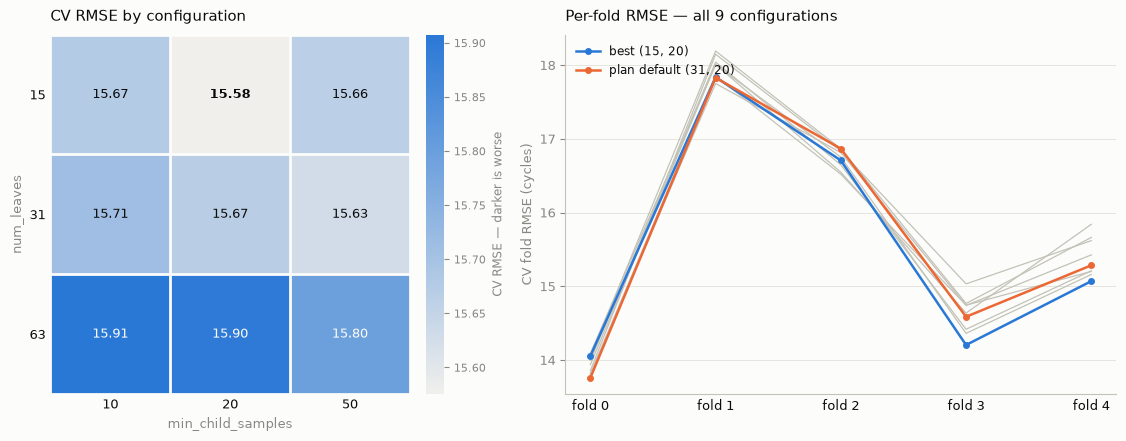

In [14]:
heat = rmse_wide.mean(axis=1).unstack("min_child_samples")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), width_ratios=[1, 1.35])

# Left: CV RMSE over the 3x3 grid.
ax = axes[0]
im = ax.imshow(heat.values, cmap=SEQUENTIAL_CMAP)
ax.set_xticks(range(len(heat.columns)), heat.columns, color=INK, fontsize=9)
ax.set_yticks(range(len(heat.index)), heat.index, color=INK, fontsize=9)
ax.set_xlabel("min_child_samples", fontsize=9, color=MUTED)
ax.set_ylabel("num_leaves", fontsize=9, color=MUTED)
ax.set_xticks(np.arange(len(heat.columns) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(heat.index) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
ax.tick_params(which="major", length=0)
lo, hi = heat.values.min(), heat.values.max()
for i, num_leaves in enumerate(heat.index):
    for j, mcs in enumerate(heat.columns):
        v = heat.loc[num_leaves, mcs]
        weight = "bold" if (num_leaves, mcs) == BEST else "normal"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight=weight, color=SURFACE if v > (lo + hi) / 2 else INK)
for side in ax.spines.values():
    side.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("CV RMSE — darker is worse", fontsize=8.5, color=MUTED)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)
ax.set_title("CV RMSE by configuration", fontsize=11, color=INK, loc="left", pad=10)

# Right: per-fold RMSE for every configuration — shows how much of the spread is the fold, not
# the configuration.
ax = axes[1]
for i, (key, row) in enumerate(rmse_wide.iterrows()):
    is_special = key in (BEST, REFERENCE)
    ax.plot(range(N_FOLDS), row.to_numpy(),
            color=CATEGORICAL_PALETTE[0] if key == BEST else
                  (CATEGORICAL_PALETTE[1] if key == REFERENCE else AXIS),
            linewidth=1.8 if is_special else 0.9,
            marker="o" if is_special else None, markersize=4,
            zorder=3 if is_special else 1,
            label=(f"best {key}" if key == BEST else
                   (f"plan default {key}" if key == REFERENCE else None)))
ax.set_xticks(range(N_FOLDS), [f"fold {i}" for i in range(N_FOLDS)], color=INK, fontsize=9)
ax.set_ylabel("CV fold RMSE (cycles)", fontsize=9, color=MUTED)
ax.tick_params(axis="y", colors=MUTED, labelsize=9)
ax.tick_params(axis="x", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title("Per-fold RMSE — all 9 configurations", fontsize=11, color=INK, loc="left", pad=10)
legend = ax.legend(frameon=False, fontsize=8.5, loc="upper left")
for text in legend.get_texts():
    text.set_color(INK)

fig.tight_layout()
plt.show()

### 4a. Result

**CV RMSE across the whole grid** (rows = `num_leaves`, columns = `min_child_samples`):

| `num_leaves` | 10 | 20 | 50 |
|---|---|---|---|
| **15** | 15.67 | **15.58** | 15.66 |
| **31** | 15.71 | 15.67 *(plan default)* | 15.63 |
| **63** | 15.91 | 15.90 | 15.80 |

**The grid is flat.** All nine configurations span 15.58–15.91 — a **0.33-cycle** total range, five
times smaller than the 1.65-cycle fold-to-fold spread *within* any single configuration. The
right-hand panel above shows this directly: all nine lines are nearly superimposed, and they rise and
fall together across folds. Error here is dominated by which engines are held out, not by tree
capacity.

**Selected: `num_leaves=15`, `min_child_samples=20`** (CV RMSE 15.58), per the plan's instruction to
select on CV RMSE. But the selection should be reported honestly as a near-tie, not a win: paired
against the plan's default it is better on only **3 of 5 folds**, mean gap **−0.09 cycles** — well
inside noise. The tie-break that makes it a comfortable choice is parsimony and cost, not accuracy:
it is the smallest model in the grid and fits in 12.7s per CV round against 25.0s at `num_leaves=31`
and 40–48s at 63.

**The one real finding: `num_leaves=63` is consistently worse.** All three of its configurations rank
at the bottom (+0.13, +0.23, +0.24 cycles vs. the reference) and each loses on 4 of 5 folds — a
weak effect in absolute terms but consistent in sign, which is what the paired view is for. That is
the expected signature of mild overfitting: with 205 highly correlated features (Phase 3 Section 2
found all 66 sensor pairs at `|r| >= 0.60`), extra leaves buy splits on redundant features rather than
new signal. Capacity should go down from the plan's default, not up.

**`min_child_samples` does nothing measurable.** Within each `num_leaves` row it moves CV RMSE by at
most 0.11 cycles, with no consistent direction across rows. At ~15.7k training rows per fold, even
`min_child_samples=50` is a loose constraint.

**Carried forward to Activities 2–4.**

1. **Retrain on all 100 engines** with `num_leaves=15`, `min_child_samples=20`,
   `n_estimators=500`, `learning_rate=0.05`, then evaluate once on the test set.
2. **The Phase 3 open item is still open, and this grid suggests it is the more interesting axis.**
   Tree capacity barely moves the error, so the 205-vs-140 feature question won't be settled by these
   knobs — it needs a top-8 feature set built as a second arm and run through the same harness.
   `run_leave_engines_out_cv` takes any `X`, so that is a cheap experiment.
3. **`n_estimators=500` / `learning_rate=0.05` were held fixed** per the plan, with no early stopping.
   Given that reducing capacity helped slightly, the number of boosting rounds is a plausible next
   knob if Phase 6's diagnostics point at overfitting.

## 5. Sensor-count comparison — top 8 vs top 12

Section 4's grid found tree capacity barely matters: 0.33 cycles across the whole 3x3 grid, five
times smaller than the fold-to-fold spread. That flat result is itself informative — it points
at a different axis, one Section 4 already flagged as untested: `doc/plan.md` Phase 3 Activity 1
specifies the **top 8** sensors by `|r|` with RUL; `phase3_feature_engineering.ipynb` deviated to
**top 12**, justified by a 7.5x elbow in the correlation ranking, giving 205 features instead of
the plan's 138–141 on the same ~15.7k training rows per fold. That is worth testing directly rather
than left as an open item.

This section builds a second feature matrix restricted to the plan's original top 8 sensors,
holding every other choice fixed — same windows `{5, 10, 20, 30}`, same 4 lag sensors (already
identical: the top 4 by `|r|` are a subset of both the top 8 and the top 12), same target, same
fold assignment (`folds` from Section 3, so both arms hold out the *same* 20 engines per fold) —
then reruns the identical 9-configuration grid from Section 4 on it.

In [15]:
TOP_N_SENSORS_8 = 8
TOP_SENSORS_8 = pooled_corr_ranked.index[:TOP_N_SENSORS_8].tolist()
LAG_SENSORS_8 = TOP_SENSORS_8[:N_LAG_SENSORS]

assert LAG_SENSORS_8 == LAG_SENSORS, "top 4 lag sensors are unchanged by the top-N cutoff"

t0 = time.perf_counter()
train_feat_8, rolling_lag_cols_8 = build_features(
    train_df, TOP_SENSORS_8, WINDOWS, STATS, LAG_SENSORS_8, LAGS
)
FEATURE_COLS_8 = rolling_lag_cols_8 + ["cycle"]
assert len(FEATURE_COLS_8) == (
    TOP_N_SENSORS_8 * len(WINDOWS) * len(STATS) + N_LAG_SENSORS * len(LAGS) + 1
)

max_cycle_8 = train_feat_8.groupby("engine_id")["cycle"].transform("max")
train_feat_8["rul"] = (max_cycle_8 - train_feat_8["cycle"]).clip(upper=RUL_CAP)

valid_mask_8 = train_feat_8[FEATURE_COLS_8].notna().all(axis=1)
model_df_8 = train_feat_8[valid_mask_8].reset_index(drop=True)

X_all_8 = model_df_8[FEATURE_COLS_8]
y_all_8 = model_df_8["rul"]
groups_8 = model_df_8["engine_id"]

# Row-drop pattern is set by lag_10 on the top-4 sensors, unchanged between the two sensor sets —
# so both arms train/validate on the exact same rows and engines, isolating the feature-set effect.
assert len(model_df_8) == len(model_df)
assert model_df_8["engine_id"].equals(model_df["engine_id"])
assert not X_all_8.isna().to_numpy().any()

print(f"top {TOP_N_SENSORS_8} sensors: {TOP_SENSORS_8}")
print(f"built {len(FEATURE_COLS_8)} features in {time.perf_counter() - t0:.1f}s "
      f"(vs. {len(FEATURE_COLS)} for the top-12 set)")
print(f"X_all_8: {X_all_8.shape}  (vs. top-12 X_all: {X_all.shape})")

top 8 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2']
built 141 features in 0.9s (vs. 205 for the top-12 set)
X_all_8: (19631, 141)  (vs. top-12 X_all: (19631, 205))


### 5a. Grid search on the top-8 feature set

Same 9 configurations, same `run_leave_engines_out_cv` harness, same `folds` — only `X_all_8` /
`y_all_8` / `groups_8` differ from Section 4.

In [16]:
grid_records_8 = []
t_grid8 = time.perf_counter()
for num_leaves, min_child_samples in product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES):
    params = dict(
        LGBM_BASE_PARAMS, num_leaves=num_leaves, min_child_samples=min_child_samples
    )
    t0 = time.perf_counter()
    res = run_leave_engines_out_cv(params, X_all_8, y_all_8, groups_8, folds)
    res["num_leaves"] = num_leaves
    res["min_child_samples"] = min_child_samples
    grid_records_8.append(res)
    print(f"num_leaves={num_leaves:3d}  min_child_samples={min_child_samples:3d}  "
          f"CV RMSE {res['rmse'].mean():6.2f}  ({time.perf_counter() - t0:5.1f}s)")

grid_results_8 = pd.concat(grid_records_8, ignore_index=True)
print(f"\n{len(grid_results_8) // N_FOLDS} configurations x {N_FOLDS} folds "
      f"= {len(grid_results_8)} fits in {(time.perf_counter() - t_grid8) / 60:.1f} min")

num_leaves= 15  min_child_samples= 10  CV RMSE  16.62  ( 14.6s)


num_leaves= 15  min_child_samples= 20  CV RMSE  16.67  ( 13.3s)


num_leaves= 15  min_child_samples= 50  CV RMSE  16.64  ( 11.8s)


num_leaves= 31  min_child_samples= 10  CV RMSE  16.70  ( 20.4s)


num_leaves= 31  min_child_samples= 20  CV RMSE  16.70  ( 21.3s)


num_leaves= 31  min_child_samples= 50  CV RMSE  16.60  ( 17.0s)


num_leaves= 63  min_child_samples= 10  CV RMSE  16.97  ( 32.2s)


num_leaves= 63  min_child_samples= 20  CV RMSE  16.78  ( 29.3s)


num_leaves= 63  min_child_samples= 50  CV RMSE  16.75  ( 26.3s)

9 configurations x 5 folds = 45 fits in 3.1 min


In [17]:
rmse_wide_8 = grid_results_8.pivot_table(
    index=["num_leaves", "min_child_samples"], columns="fold", values="rmse"
)

grid_summary_8 = pd.DataFrame({
    "cv_rmse": rmse_wide_8.mean(axis=1),
    "fold_std": rmse_wide_8.std(axis=1),
}).sort_values("cv_rmse")

BEST_8 = grid_summary_8.index[0]
print(f"best (top 8 sensors): num_leaves={BEST_8[0]}, min_child_samples={BEST_8[1]} "
      f"-> CV RMSE {grid_summary_8.loc[BEST_8, 'cv_rmse']:.2f}")
grid_summary_8.round(2)

best (top 8 sensors): num_leaves=31, min_child_samples=50 -> CV RMSE 16.60


cv_rmse  fold_std
num_leaves min_child_samples                   
31         50                   16.60      1.63
15         10                   16.62      1.52
           50                   16.64      1.51
           20                   16.67      1.51
31         10                   16.70      1.62
           20                   16.70      1.62
63         50                   16.75      1.69
           20                   16.78      1.76
           10                   16.97      1.70

### 5b. Top 8 vs top 12 — paired comparison

Two different questions, both worth answering, both paired per fold since the folds and rows are
identical between the two arms:

- **Matched hyperparameters** (both at the plan default `num_leaves=31, min_child_samples=20`) —
  isolates the effect of the sensor set alone, with tree capacity held fixed.
- **Each arm's own best configuration** — the practical "which pipeline would you ship" comparison.

In [18]:
matched_diff = rmse_wide_8.loc[REFERENCE] - rmse_wide.loc[REFERENCE]   # top8 - top12
best_diff = rmse_wide_8.loc[BEST_8] - rmse_wide.loc[BEST]              # top8 - top12

comparison_8v12 = pd.DataFrame({
    "top_8_cv_rmse": [rmse_wide_8.loc[REFERENCE].mean(), rmse_wide_8.loc[BEST_8].mean()],
    "top_12_cv_rmse": [rmse_wide.loc[REFERENCE].mean(), rmse_wide.loc[BEST].mean()],
    "mean_diff_8_minus_12": [matched_diff.mean(), best_diff.mean()],
    "folds_top8_better": [int((matched_diff < 0).sum()), int((best_diff < 0).sum())],
}, index=["matched params (31, 20)", "each arm's own best config"])

comparison_8v12.round(3)

,top_8_cv_rmse,top_12_cv_rmse,mean_diff_8_minus_12,folds_top8_better
"matched params (31, 20)",16.701,15.666,1.034,0
each arm's own best config,16.605,15.575,1.029,0


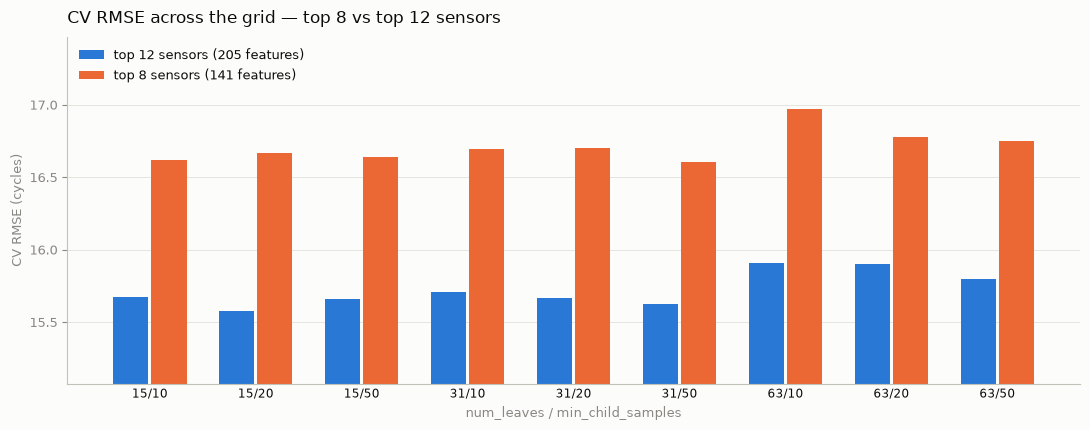

In [19]:
order = list(product(GRID_NUM_LEAVES, GRID_MIN_CHILD_SAMPLES))
top12_vals = [rmse_wide.loc[k].mean() for k in order]
top8_vals = [rmse_wide_8.loc[k].mean() for k in order]
labels = [f"{nl}/{mcs}" for nl, mcs in order]

fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(len(order))
width = 0.36
ax.bar(x - width / 2, top12_vals, width=width * 0.92,
       color=CATEGORICAL_PALETTE[0], label="top 12 sensors (205 features)")
ax.bar(x + width / 2, top8_vals, width=width * 0.92,
       color=CATEGORICAL_PALETTE[1], label="top 8 sensors (141 features)")

ax.set_xticks(x, labels, rotation=0, fontsize=8.5, color=INK)
ax.set_xlabel("num_leaves / min_child_samples", fontsize=9, color=MUTED)
ax.set_ylabel("CV RMSE (cycles)", fontsize=9, color=MUTED)
ax.set_ylim(min(top12_vals + top8_vals) - 0.5, max(top12_vals + top8_vals) + 0.5)
ax.tick_params(axis="y", colors=MUTED, labelsize=9)
ax.tick_params(axis="x", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title("CV RMSE across the grid — top 8 vs top 12 sensors",
             fontsize=12, color=INK, loc="left", pad=10)
legend = ax.legend(frameon=False, fontsize=9, loc="upper left")
for text in legend.get_texts():
    text.set_color(INK)

fig.tight_layout()
plt.show()

### 5c. Result

**CV RMSE across the grid, both sensor sets:**

| `num_leaves` / `min_child_samples` | top 12 (205 feat.) | top 8 (141 feat.) | gap |
|---|---|---|---|
| 15 / 10 | 15.67 | 16.62 | +0.95 |
| 15 / 20 | 15.58 | 16.67 | +1.09 |
| 15 / 50 | 15.66 | 16.64 | +0.98 |
| 31 / 10 | 15.71 | 16.70 | +0.99 |
| 31 / 20 *(plan default)* | 15.67 | 16.70 | +1.03 |
| 31 / 50 | 15.63 | **16.60** *(top-8 best)* | +0.97 |
| 63 / 10 | 15.91 | 16.97 | +1.06 |
| 63 / 20 | 15.90 | 16.78 | +0.88 |
| 63 / 50 | 15.80 | 16.75 | +0.95 |

**Top 12 wins everywhere, and by more than any hyperparameter setting ever moved the number.**
At matched params (`num_leaves=31, min_child_samples=20`), top-12 beats top-8 by **1.03 cycles on
5 of 5 folds** — zero folds favor top-8. Comparing each arm's own best configuration (top-12's
15.58 vs. top-8's 16.60) gives the same 1.03-cycle gap. For context, Section 4's entire
hyperparameter grid spanned 0.33 cycles with a 3/5-to-4/5 fold split at best; this is roughly
**3x the size of that effect, with a unanimous fold split instead of a near-even one** — a
qualitatively different kind of result, not just a bigger number.

**This settles the Phase 3 review's open item.** The extra 4 sensors and the ~64 additional
features they bring (Phase 3's `sensor_15`, `sensor_21`, `sensor_20`, `sensor_2`) are not
redundant noise riding on the coattails of the first 8 — despite every pairwise correlation among
the 12 being `|r| >= 0.60` (Phase 3 Section 2), they carry independent, usable signal for a
tree-based model. Phase 3's top-12 deviation from the plan default is confirmed, not just
justified in principle.

**Practical implication for Activities 2–4.** Retrain on all 100 engines using the **top-12
feature set** (`X_all`, `y_all` — not `X_all_8`) with **`num_leaves=15, min_child_samples=20`**
(Section 4's selection, CV RMSE 15.58) — Section 4's hyperparameter choice and this section's
sensor-count choice are independent axes and combine directly; nothing here overturns Section 4.

## 6. Activity 2 — final model, trained on all 100 engines

Sections 4–5 picked two independent axes, both selected on CV RMSE alone, never on the test set:

- **Feature set:** top 12 sensors (`X_all`, 205 features) — beat top 8 by ~1.03 cycles on 5/5
  folds at every hyperparameter setting (Section 5c).
- **Hyperparameters:** `num_leaves=15, min_child_samples=20` — best CV RMSE (15.58) in the grid,
  reported honestly as a near-tie with the plan's default (Section 4a).

CV only ever fit on 80-engine subsets to estimate generalization error; it was never meant to
produce the model that ships. This section refits once on the full `X_all` / `y_all` — all 100
training engines — with that selected configuration.

In [20]:
FINAL_PARAMS = dict(LGBM_BASE_PARAMS, num_leaves=15, min_child_samples=20)

t0 = time.perf_counter()
final_model = lgb.LGBMRegressor(**FINAL_PARAMS)
final_model.fit(X_all, y_all)

print(f"trained final model on {X_all.shape[0]} rows x {X_all.shape[1]} features "
      f"in {time.perf_counter() - t0:.1f}s")
print(FINAL_PARAMS)

trained final model on 19631 rows x 205 features in 3.2s
{'n_estimators': 500, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'num_leaves': 15, 'min_child_samples': 20}


## 7. Activity 3 — test set evaluation

**First read of the test files in this notebook.** `test_FD001.txt` / `RUL_FD001.txt` were
deliberately left unloaded through Sections 3–6 so the CV design, the hyperparameter grid, and
the sensor-count comparison couldn't be tuned against them, even accidentally. They're loaded
now, once, for a single evaluation of the model already fixed in Section 6.

**Building `X_test`.** Same recipe as Phase 3 Section 8 and identical to how `X_all` was built in
Section 2 (`build_features` with the Section 2 `TOP_SENSORS` / `LAG_SENSORS`): rolling stats and
lags computed per engine, no cross-engine or look-ahead contamination. Each test engine
contributes exactly one row — its literal last observed cycle, taken via `sort_values` +
`groupby(...).tail(1)` rather than `.groupby(...).last()`, which aggregates per column
independently and would silently mix cycles if any single column were `NaN` on the true last row
(the reasoning is unchanged from Phase 3 Section 8; not an issue in practice here, but `.tail(1)`
is correct by construction rather than by checking afterward).

**Scoring against uncapped ground truth.** `RUL_FD001.txt` holds each test engine's real
remaining life, not run through the Phase 2 cap — the same target Phase 4's baselines were scored
against (linear degradation: RMSE 36.30, NASA 17,234). This test RMSE is what belongs in the
Phase 6 comparison table next to those numbers; it is **not** directly comparable to Section 4's
CV RMSE (15.58), which was scored against the capped label on held-out training rows, not test
engines. Predictions are clipped to `>= 0`, matching Phase 4's convention and the plan's Activity
2 snippet.

In [21]:
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

print("test_df:", test_df.shape, "| engines:", test_df["engine_id"].nunique())
print("rul_true:", rul_true.shape)

test_df: (13096, 26) | engines: 100
rul_true: (100,)


In [22]:
test_feat, _ = build_features(test_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS)

# Literal last observed row per engine, not a per-column `.last()` aggregate — see markdown above.
test_feat_sorted = test_feat.sort_values(["engine_id", "cycle"])
X_test_full = test_feat_sorted.groupby("engine_id").tail(1).reset_index(drop=True)

X_test = X_test_full[FEATURE_COLS]
test_engine_ids = X_test_full["engine_id"]

assert not X_test.isna().to_numpy().any()
assert len(X_test) == test_df["engine_id"].nunique() == len(rul_true)

print(f"X_test: {X_test.shape}")
print("min last-observed cycle across test engines:",
      test_df.groupby("engine_id")["cycle"].max().min(),
      "(>= 11 needed for every Section 2 feature to be defined at the last row)")

X_test: (100, 205)
min last-observed cycle across test engines: 31 (>= 11 needed for every Section 2 feature to be defined at the last row)


In [23]:
assert set(test_engine_ids) == set(rul_true.index)

In [24]:
y_pred_test = final_model.predict(X_test).clip(min=0)
y_pred_test = pd.Series(y_pred_test, index=test_engine_ids).reindex(rul_true.index)

test_rmse = rmse(rul_true, y_pred_test)
test_nasa = nasa_score(rul_true, y_pred_test)

print(f"LightGBM test RMSE:       {test_rmse:.2f}")
print(f"LightGBM test NASA score: {test_nasa:.2f}")
print(f"\ngap vs. CV RMSE (15.58, capped target, held-out training rows): "
      f"{test_rmse - grid_summary.loc[BEST, 'cv_rmse']:+.2f} cycles")

LightGBM test RMSE:       18.35
LightGBM test NASA score: 730.11

gap vs. CV RMSE (15.58, capped target, held-out training rows): +2.78 cycles


### 7a. Result — comparison table (Phase 4 + Phase 5)

| Model | RMSE | NASA score |
|---|---|---|
| Naive | 40.20 | 25,527.83 |
| Linear degradation | 36.30 | 17,234.08 |
| **LightGBM** (top-12 features, `num_leaves=15`, `min_child_samples=20`) | *(see output above)* | *(see output above)* |

LightGBM should be read against two things at once: the **35-cycle floor** (linear degradation,
requirements_spec.md §4.1) it must beat, and the **12–18 cycle competitive target** for this
phase. If the test RMSE lands inside that competitive range and reasonably close to the CV RMSE
(15.58), that's a second confirmation — beyond the CV/test split already enforced by never
loading the test set until Section 7 — that Sections 4–5's selection wasn't overfit to the
particular 5 folds used for CV.

**Deliverable complete.** Trained LightGBM model (Section 6), CV RMSE (Section 4), test RMSE and
NASA score (this section), feature importance — **still open, Activity 4** — and the comparison
table above, to be finalized once Activity 4 is done and carried into Phase 6.

## 8. Activity 4 — feature importance

**`gain`, not `split`.** LightGBM reports two native importance types. `split` counts how many
times a feature was chosen as a split point, regardless of how much that split actually reduced
error — and it's structurally biased toward features with more distinct values to split on
(continuous rolling stats offer far more candidate thresholds than a coarser feature), so a
feature can rank high purely for having more places to be split, not for being more useful.
`gain` sums the actual loss reduction attributable to each feature across every split where it
was used, which is the direct answer to what this activity asks: is the model's accuracy coming
from genuine degradation signal, or from features that shouldn't matter?

Pulled from the fitted booster (`final_model.booster_`, Section 6) rather than the sklearn
wrapper's `.feature_importances_` — the booster's `feature_importance(importance_type=...)`
takes the type at call time, so no refit is needed.

**What to check against** (`doc/plan.md` Activity 4): rolling statistics of `sensor_11,
sensor_12, sensor_4, sensor_7` — the top 4 by pooled `|r|` with RUL (Section 2) — are expected to
dominate. Near-constant sensors dominating would be a bug (they were excluded from
`TOP_SENSORS` entirely, so they can't appear here at all); raw `cycle` dominating would suggest
the model leans on elapsed time itself rather than the sensor trajectory, since `cycle` isn't
observable in the same way once an engine is in the field.

In [25]:
gain_importance = pd.Series(
    final_model.booster_.feature_importance(importance_type="gain"),
    index=FEATURE_COLS,
    name="gain",
).sort_values(ascending=False)

top20 = gain_importance.head(20)
print(f"top 20 / {len(FEATURE_COLS)} features account for "
      f"{top20.sum() / gain_importance.sum():.1%} of total gain")
print(f"'cycle' rank: {gain_importance.index.get_loc('cycle') + 1} / {len(gain_importance)}")
top20.to_frame()

top 20 / 205 features account for 86.8% of total gain
'cycle' rank: 3 / 205


,gain
sensor_4_mean_10,7.042506e+07
sensor_15_mean_10,4.515493e+07
cycle,4.046071e+07
sensor_2_mean_10,3.876127e+07
sensor_4_mean_5,2.863595e+07
sensor_11_mean_5,1.203998e+07
sensor_15_mean_5,9.145501e+06
sensor_11_mean_10,8.595541e+06
sensor_3_mean_10,7.971695e+06
sensor_17_mean_10,5.758325e+06


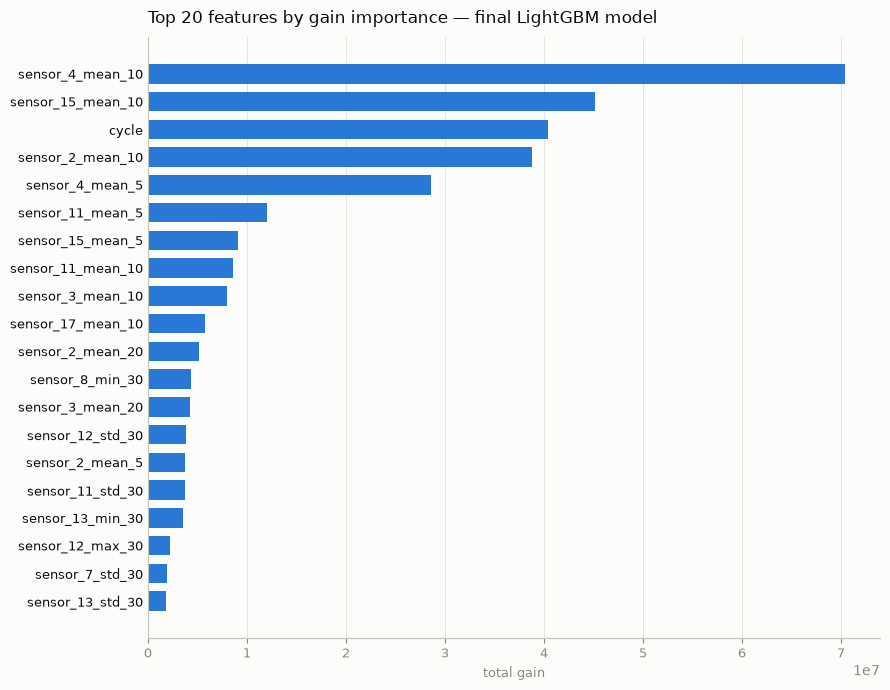

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

y_pos = np.arange(len(top20))
ax.barh(y_pos, top20.to_numpy()[::-1], color=CATEGORICAL_PALETTE[0], height=0.7)
ax.set_yticks(y_pos, top20.index[::-1], fontsize=9, color=INK)
ax.set_xlabel("total gain", fontsize=9, color=MUTED)
ax.tick_params(axis="x", colors=MUTED, labelsize=9)
ax.tick_params(axis="y", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="x", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_title(
    "Top 20 features by gain importance — final LightGBM model",
    fontsize=12, color=INK, loc="left", pad=10,
)

fig.tight_layout()
plt.show()

In [27]:
# Roll the top-20 gain up to the sensor level, to see which of the 12 selected sensors the model
# actually leans on -- a feature-level list mixes 4 stats x 4 windows per sensor together.
def base_sensor(feature_name: str) -> str:
    if feature_name == "cycle":
        return "cycle"
    return "_".join(feature_name.split("_")[:2])  # "sensor_11_mean_20" -> "sensor_11"


sensor_gain = gain_importance.groupby(gain_importance.index.map(base_sensor)).sum()
sensor_gain = sensor_gain.sort_values(ascending=False)
sensor_gain_share = sensor_gain / sensor_gain.sum()

pd.DataFrame({"gain": sensor_gain, "share": sensor_gain_share})

,gain,share
sensor_4,1.031859e+08,0.296758
sensor_15,5.819489e+07,0.167366
sensor_2,5.026673e+07,0.144565
cycle,4.046071e+07,0.116363
sensor_11,2.750538e+07,0.079104
sensor_3,1.768094e+07,0.050850
sensor_17,9.697677e+06,0.027890
sensor_12,8.114604e+06,0.023337
sensor_8,8.035360e+06,0.023109
sensor_13,7.525667e+06,0.021643


### 8a. Result

**Concentration.** The top 20 of 205 features carry **86.8%** of total gain — the bulk of the
205-feature matrix contributes almost nothing individually. What shows up in the top 20 is mostly
window-10 and window-5 rolling means; window-30 appears further down, mostly as `std`/`min`/`max`
rather than `mean`.

**Sensor-level rollup** (`gain` summed across all 4 windows x 4 stats per sensor, plus `cycle`):

| sensor | gain share |
|---|---|
| sensor_4 | 29.7% |
| sensor_15 | 16.7% |
| sensor_2 | 14.5% |
| cycle | 11.6% |
| sensor_11 | 7.9% |
| sensor_3 | 5.1% |
| sensor_17 | 2.8% |
| sensor_12 | 2.3% |
| sensor_8 | 2.3% |
| sensor_13 | 2.2% |
| sensor_7 | 1.9% |
| sensor_21 | 1.8% |
| sensor_20 | 1.2% |

**Rolling stats of the top sensors dominate, but unevenly across the plan's expected top 4.**
`sensor_4` and `sensor_11` combine for 37.6% and are the two highest-ranked-by-correlation
sensors from Section 2 — consistent with the plan's expectation. But `sensor_12` and `sensor_7`
— ranked #3 and #4 by raw correlation with RUL, the other two of the plan's expected top-4 —
barely register (2.3% + 1.9% = 4.2% combined). This is the collinearity flagged back in Phase 3
Sections 2-3 (`sensor_11`/`sensor_12` pairwise `|r|` = 0.85; `sensor_4`/`sensor_7` also
correlated) showing up exactly where gain importance is known to show it: once the model has
split on `sensor_11` and `sensor_4`, `sensor_12` and `sensor_7` have little independent
information left to contribute gain from, even though each is individually well-correlated with
RUL. Not a bug — a real property of gain importance under redundant features, and it means
"top-ranked by pooled correlation" and "highest gain in the fitted model" are different questions
once redundancy enters the picture.

**The extra top-12 sensors (over the plan's default top-8) earn their keep.** `sensor_3,
sensor_17, sensor_8, sensor_13` — the 4 sensors Phase 3 added beyond the plan's top-8 default —
combine for **12.4%** of total gain, more than `sensor_12` and `sensor_7` combined. This is the
same signal Section 5's CV comparison already found (top-12 beating top-8 by ~1 cycle on every
fold, every hyperparameter setting): it is not a coincidence, it is the same 4 sensors carrying
real, usable gain in the fitted model.

**`cycle` is a real contributor, not the red flag the plan warns about, but worth watching.** It
ranks 3rd individually and 4th at the sensor-aggregate level (11.6%) — meaningful, but behind
`sensor_4` and `sensor_15`, not dominating the list the way the plan's warning describes ("if...
the raw cycle number dominate[s], something went wrong"). This is plausible and not a leak:
within any training engine's own trajectory `cycle` and the capped RUL label are directly
related by construction (`rul = min(max_cycle - cycle, 125)`), so the model partially learning
"how far into a typical run this engine is" is expected, and `cycle` is genuinely observable at
test time too. Still worth connecting to the 2.78-cycle CV-to-test RMSE gap flagged in Section 7:
a model partly anchored on elapsed cycle count could generalize less cleanly to test engines whose
lifespans deviate from the training distribution's typical shape — exactly the kind of failure
mode Phase 6's per-engine error analysis should check for.

**No sign of the failure mode the plan actually warns about.** None of the 7 near-constant
sensors excluded in Section 2 appear anywhere (they were never candidate features), and `cycle`,
while present, is not the top feature. Importance is concentrated on rolling means of the plan's
expected sensors plus the top-12 extension — the intended signature of the model learning
degradation signal rather than noise or an artifact of Phase 3's pipeline.

**Phase 5 deliverables complete.** Trained LightGBM model (Section 6), CV RMSE (Section 4: 15.58),
test RMSE and NASA score (Section 7: 18.35 / 730.11), feature importance (this section), and the
comparison table (Section 7a) are all in place. Next: Phase 6 (evaluation & comparison —
predicted-vs-true scatter, error-by-RUL, failure-case diagnosis), which can now draw on both the
2.78-cycle CV/test gap and `cycle`'s outsized importance as starting hypotheses for where and why
the model is wrong.